In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import joblib

In [2]:
def calculate_angle(a, b, c):
    """
    Calculates the angle in degrees between three points (a, b, c),
    where 'b' is the vertex.
    """
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba, bc = a - b, c - b
    dot_product = np.dot(ba, bc)
    norm_ba, norm_bc = np.linalg.norm(ba), np.linalg.norm(bc)
    if norm_ba == 0 or norm_bc == 0:
        return 0.0
    cosine_angle = np.clip(dot_product / (norm_ba * norm_bc), -1.0, 1.0)
    return np.degrees(np.arccos(cosine_angle))


def add_pushup_angles(df):
    df = df.copy()

    left_elbow_angles, right_elbow_angles = [], []
    left_shoulder_angles, right_shoulder_angles = [], []
    left_hip_angles, right_hip_angles = [], []
    torso_angles = []
    left_wrist_angles, right_wrist_angles = [], []
    shoulder_elevs_left, shoulder_elevs_right = [], []
    torso_hip_drifts = []


    for _, row in df.iterrows():
        # --- Landmarks (Left) ---
        left_shoulder = [row['LEFT_SHOULDER_x'], row['LEFT_SHOULDER_y']]
        left_elbow = [row['LEFT_ELBOW_x'], row['LEFT_ELBOW_y']]
        left_wrist = [row['LEFT_WRIST_x'], row['LEFT_WRIST_y']]
        left_hip = [row['LEFT_HIP_x'], row['LEFT_HIP_y']]
        left_knee = [row['LEFT_KNEE_x'], row['LEFT_KNEE_y']]

        # --- Landmarks (Right) ---
        right_shoulder = [row['RIGHT_SHOULDER_x'], row['RIGHT_SHOULDER_y']]
        right_elbow = [row['RIGHT_ELBOW_x'], row['RIGHT_ELBOW_y']]
        right_wrist = [row['RIGHT_WRIST_x'], row['RIGHT_WRIST_y']]
        right_hip = [row['RIGHT_HIP_x'], row['RIGHT_HIP_y']]
        right_knee = [row['RIGHT_KNEE_x'], row['RIGHT_KNEE_y']]

        # ANGLES:
        # Elbow Flexion Angle (Shoulder → Elbow → Wrist)
        left_elbow_angle = calculate_angle(left_shoulder, left_elbow, left_wrist)
        right_elbow_angle = calculate_angle(right_shoulder, right_elbow, right_wrist)

        # Shoulder Angle (Elbow → Shoulder → Hip)
        left_shoulder_angle = calculate_angle(left_elbow, left_shoulder, left_hip)
        right_shoulder_angle = calculate_angle(right_elbow, right_shoulder, right_hip)

        # Hip Angle (Shoulder → Hip → Knee) – core alignment
        left_hip_angle = calculate_angle(left_shoulder, left_hip, left_knee)
        right_hip_angle = calculate_angle(right_shoulder, right_hip, right_knee)

        # Torso Angle (Shoulder → Hip → Vertical reference)
        hip_vertical = [left_hip[0], left_hip[1] + 1]
        torso_angle = calculate_angle(left_shoulder, left_hip, hip_vertical)

        # Wrist Angle (Elbow → Wrist → Horizontal)
        left_wrist_horizontal = [left_wrist[0] + 1, left_wrist[1]]
        right_wrist_horizontal = [right_wrist[0] + 1, right_wrist[1]]

        left_wrist_angle = calculate_angle(left_elbow, left_wrist, left_wrist_horizontal)
        right_wrist_angle = calculate_angle(right_elbow, right_wrist, right_wrist_horizontal)

        # Shoulder Elevation (shrugging detection)
        left_shoulder_elev = left_shoulder[1] - left_hip[1]
        right_shoulder_elev = right_shoulder[1] - right_hip[1]

        # Torso–hip drift (detects hips going forward/back)
        torso_hip_drift = left_hip[0] - left_shoulder[0]



        # Append to lists
        left_elbow_angles.append(left_elbow_angle)
        right_elbow_angles.append(right_elbow_angle)

        left_shoulder_angles.append(left_shoulder_angle)
        right_shoulder_angles.append(right_shoulder_angle)

        left_hip_angles.append(left_hip_angle)
        right_hip_angles.append(right_hip_angle)

        torso_angles.append(torso_angle)

        left_wrist_angles.append(left_wrist_angle)
        right_wrist_angles.append(right_wrist_angle)

        shoulder_elevs_left.append(left_shoulder_elev)
        shoulder_elevs_right.append(right_shoulder_elev)

        torso_hip_drifts.append(torso_hip_drift)

    # Add columns to dataframe
    df['left_elbow_angle'] = left_elbow_angles
    df['right_elbow_angle'] = right_elbow_angles

    df['left_shoulder_angle'] = left_shoulder_angles
    df['right_shoulder_angle'] = right_shoulder_angles

    df['left_hip_angle'] = left_hip_angles
    df['right_hip_angle'] = right_hip_angles

    df['torso_angle'] = torso_angles

    df['left_wrist_angle'] = left_wrist_angles
    df['right_wrist_angle'] = right_wrist_angles

    df['left_shoulder_elevation'] = shoulder_elevs_left
    df['right_shoulder_elevation'] = shoulder_elevs_right

    df['torso_hip_drift'] = torso_hip_drifts

    return df

In [3]:
# Load and preprocess data
print("=" * 60)
print("LOADING DATA")
print("=" * 60)

df = pd.read_csv(r"D:\رواد\Lateral_Raises_code\Gym-Coach-Lateral_Raises\pose_landmarks_all_lateral_raises.csv" )
print(f"Initial shape: {df.shape}")

df = add_pushup_angles(df)
df = df.sort_values(by=["video_name", "frame"]).reset_index(drop=True)

# Drop face landmarks except nose
columns_to_drop = [
    # Face landmarks
    'LEFT_EYE_INNER_x', 'LEFT_EYE_INNER_y', 'LEFT_EYE_INNER_visibility',
    'LEFT_EYE_x', 'LEFT_EYE_y', 'LEFT_EYE_visibility',
    'LEFT_EYE_OUTER_x', 'LEFT_EYE_OUTER_y', 'LEFT_EYE_OUTER_visibility',
    'RIGHT_EYE_INNER_x', 'RIGHT_EYE_INNER_y', 'RIGHT_EYE_INNER_visibility',
    'RIGHT_EYE_x', 'RIGHT_EYE_y', 'RIGHT_EYE_visibility',
    'RIGHT_EYE_OUTER_x', 'RIGHT_EYE_OUTER_y', 'RIGHT_EYE_OUTER_visibility',
    'LEFT_EAR_x', 'LEFT_EAR_y', 'LEFT_EAR_visibility',
    'RIGHT_EAR_x', 'RIGHT_EAR_y', 'RIGHT_EAR_visibility',
    'MOUTH_LEFT_x', 'MOUTH_LEFT_y', 'MOUTH_LEFT_visibility',
    'MOUTH_RIGHT_x', 'MOUTH_RIGHT_y', 'MOUTH_RIGHT_visibility'
]

# Only drop columns that exist in the dataframe
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df.drop(columns=existing_columns_to_drop, inplace=True)

print(f"Dropped {len(existing_columns_to_drop)} columns (face)")
print(f"Shape after dropping: {df.shape}")

# Define metadata columns (no phase or rep_counter)
meta_cols = ["frame", "video_name"]
pose_cols = [c for c in df.columns if c not in meta_cols]

# Scale numeric features
scaler = StandardScaler()
df[pose_cols] = scaler.fit_transform(df[pose_cols])

LOADING DATA
Initial shape: (28178, 101)
Dropped 30 columns (face)
Shape after dropping: (28178, 83)


In [4]:
def create_windows_for_video(data, window_size=30, stride=5):
    X = []
    for i in range(0, len(data) - window_size, stride):
        X.append(data[i:i+window_size])
    return np.array(X)

X_all = []
for _, group in df.groupby("video_name"):
    X_tmp = create_windows_for_video(group[pose_cols].values, window_size=30, stride=5)
    if len(X_tmp) > 0:  # skip empty videos
        X_all.append(X_tmp)

# Only concatenate non-empty arrays
X_all = np.concatenate(X_all, axis=0)
print(f"Size of windowed data: X={X_all.shape}")


Size of windowed data: X=(5265, 30, 81)


In [5]:
X_train, X_temp = train_test_split(X_all, test_size=0.2, random_state=42)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, X_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, X_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, X_test_t), batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [6]:
class TransformerAutoencoder(nn.Module):
    def __init__(self, num_features, seq_len, d_model=128, nhead=8, num_layers=6):
        super().__init__()
        self.seq_len = seq_len

        # Encoder
        self.input_proj = nn.Linear(num_features, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Decoder
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, num_features)

    def forward(self, x):
        z = self.input_proj(x)
        memory = self.encoder(z)
        reconstructed = self.decoder(z, memory)
        recon_out = self.output_proj(reconstructed)
        return recon_out

In [7]:
seq_len = X_train.shape[1]
num_features = X_train.shape[2]

print(f"Sequence Length: {seq_len}")
print(f"Number of Features: {num_features}")

model = TransformerAutoencoder(num_features, seq_len).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
mse_loss = nn.MSELoss()
epochs = 30


Sequence Length: 30
Number of Features: 81


In [8]:
train_losses = []
val_losses = []
best_val_loss = float('inf') 
BEST_MODEL_PATH = "pushup_transformer_autoencoder.pth"

for epoch in range(epochs):
    model.train()
    train_loss, train_correct, total = 0, 0, 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        class_out = model(x_batch)

        recon_out = model(x_batch)
        loss = mse_loss(recon_out, x_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for x_val, _ in val_loader:
            x_val = x_val.to(device)
            recon_out = model(x_val)
            loss = mse_loss(recon_out, x_val)
            val_loss += loss.item()

    avg_train_loss = train_loss/len(train_loader)
    avg_val_loss = val_loss/len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    
    # --- The Logic to Save the Best Model ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"✅ New best model saved! Val Loss: {best_val_loss:.4f}")

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f}")



KeyboardInterrupt: 

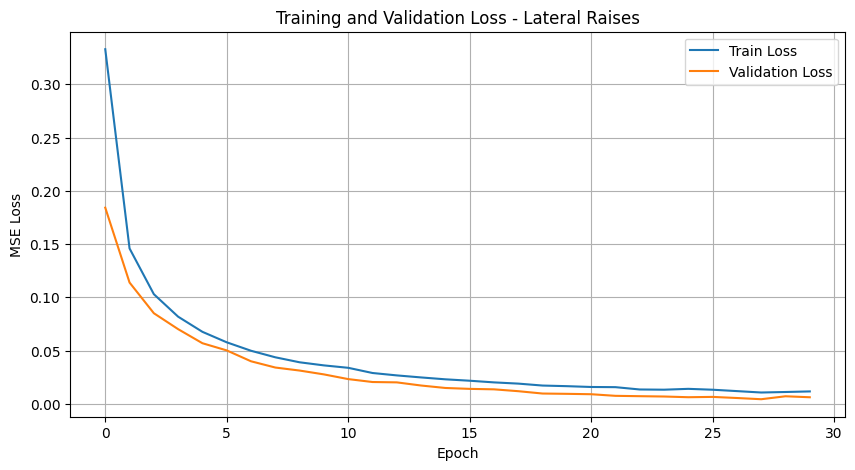

In [ ]:
# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss - Lateral Raises')
plt.legend()
plt.grid(True)
plt.show()

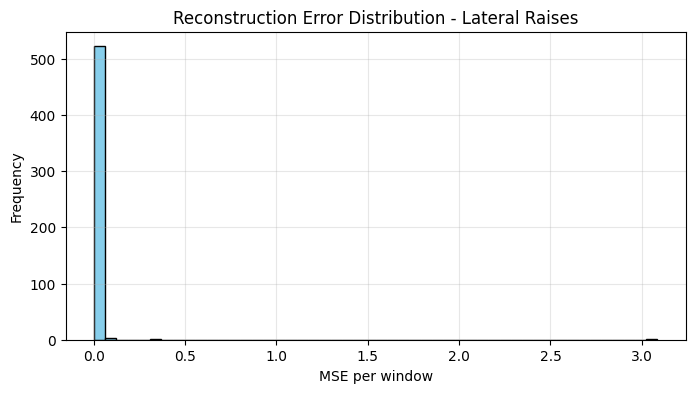

In [ ]:
# Evaluate on test set
model.eval()
recon_errors = []
with torch.no_grad():
    for x_batch, _ in test_loader:
        x_batch = x_batch.to(device)
        recon_out = model(x_batch)
        batch_error = torch.mean((x_batch - recon_out) ** 2, dim=(1, 2)).cpu().numpy()
        recon_errors.extend(batch_error)

recon_errors = np.array(recon_errors)

plt.figure(figsize=(8, 4))
plt.hist(recon_errors, bins=50, color='skyblue', edgecolor='black')
plt.title("Reconstruction Error Distribution - Lateral Raises")
plt.xlabel("MSE per window")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
joblib.dump(scaler, "pose_scaler_lateral_raises.pkl")
print("Scaler saved.")

Autoencoder model and scaler saved.
